# 风险作业 – Steps 1–3: Dual-Portfolio Markowitz Analysis

Two portfolios are built:
- **Chip / Compute** (`portfolio_chip`): compute-infrastructure focused
- **Value & Growth** (`portfolio_value_n_growth`): diversified blue-chip + growth

Each portfolio is independently optimised using Markowitz Mean-Variance theory.
Results are compared side-by-side, and final weights printed at the bottom.

In [1]:
import rqdatac as rq
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

rq.init()

# ─────────────────────────────────────────
# 1. DEFINE THE TWO PORTFOLIOS
# ─────────────────────────────────────────

start_date = "2023-01-01"
end_date   = "2025-12-31"

portfolio_chip = [
    "600406.XSHG",   # 国电南瑞 – power/chip infra
    "601868.XSHG",   # 中国能建 – energy construction
    "600089.XSHG",   # 特变电工 – UHV transformers
    "601126.XSHG",   # 四方股份 – power automation
    "002837.XSHE",   # 英维克 – data-centre cooling
    "000815.XSHE",   # 美利云 – IDC / cloud infra
    "300442.XSHE",   # 芯能科技 – semiconductor energy
    "301308.XSHE",   # 华勤技术 – ODM / hardware
    "300308.XSHE",   # 中际旭创 – optical transceivers
    "002929.XSHE",   # 润建股份 – 5G / data-centre engineering
]

portfolio_value_n_growth = [
    "600030.XSHG",   # 中信证券 – brokerage / value
    "600519.XSHG",   # 贵州茅台 – consumer staples / value
    "600900.XSHG",   # 长江电力 – utilities / dividend
    "601398.XSHG",   # 工商银行 – big-4 bank / value
    "601899.XSHG",   # 紫金矿业 – gold / commodities
    "601012.XSHG",   # 隆基绿能 – solar / growth
    "688256.XSHG",   # 寒武纪 – AI chips / growth (STAR)
    "688041.XSHG",   # 海光信息 – CPU / growth (STAR)
    "601127.XSHG",   # 赛力斯 – NEV / growth
    "603019.XSHG",   # 中科曙光 – AI servers / growth
]

# ─────────────────────────────────────────
# 2. FETCH PRICE DATA FOR BOTH SETS
# ─────────────────────────────────────────

def fetch_prices(tickers, start_date, end_date):
    """Fetch adjusted close prices and return a wide DataFrame (date x ticker)."""
    df = rq.get_price(
        tickers,
        start_date=start_date,
        end_date=end_date,
        fields=['close'],
        expect_df=False,
        adjust_type='none'
    )
    df.dropna(axis=1, how='any', inplace=True)
    return df

prices_chip = fetch_prices(portfolio_chip, start_date, end_date)
prices_vng  = fetch_prices(portfolio_value_n_growth, start_date, end_date)

print(f"Chip portfolio  : {prices_chip.shape[1]} stocks x {prices_chip.shape[0]} days")
print(f"V&G  portfolio  : {prices_vng.shape[1]}  stocks x {prices_vng.shape[0]} days")


Chip portfolio  : 10 stocks x 727 days
V&G  portfolio  : 10  stocks x 727 days


In [2]:
# ─────────────────────────────────────────
# 3. SHARED ASSUMPTIONS
# ─────────────────────────────────────────
TRADING_DAYS  = 242          # avg A-share trading days / year
RISK_FREE_RATE = 0.02        # 2% p.a.  (≈ 1-yr China deposit rate)
MIN_WEIGHT    = 0.01         # no short selling
MAX_WEIGHT    = 0.30         # max 30% per stock

# ─────────────────────────────────────────
# 4. HELPER FUNCTIONS
# ─────────────────────────────────────────
import warnings

def compute_mu_cov(prices):
    returns = prices.pct_change().dropna()
    mu  = returns.mean() * TRADING_DAYS
    cov = returns.cov()  * TRADING_DAYS
    return returns, mu, cov

def portfolio_performance(w, mu, cov):
    ret    = w @ mu
    vol    = np.sqrt(w @ cov @ w)
    sharpe = (ret - RISK_FREE_RATE) / vol
    return ret, vol, sharpe

def neg_sharpe(w, mu, cov):
    return -portfolio_performance(w, mu, cov)[2]

def portfolio_vol(w, mu, cov):
    return portfolio_performance(w, mu, cov)[1]

def make_bounds_constraints(n):
    bounds = tuple((MIN_WEIGHT, MAX_WEIGHT) for _ in range(n))
    constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
    return bounds, constraints

def run_slsqp(fun, w0, args, bounds, constraints):
    with warnings.catch_warnings():
        warnings.filterwarnings(
            "ignore",
            message="Values in x were outside bounds during a minimize step, clipping to bounds",
            category=RuntimeWarning,
            module="scipy.optimize._slsqp_py"
        )
        return minimize(
            fun,
            w0,
            args=args,
            method='SLSQP',
            bounds=bounds,
            constraints=constraints,
            options={'maxiter': 300, 'ftol': 1e-9, 'disp': False}
        )

def optimise(prices):
    """Run Markowitz optimisation and return a result dict."""
    rets, mu, cov = compute_mu_cov(prices)
    n  = len(mu)
    w0 = np.ones(n) / n
    bounds, constraints = make_bounds_constraints(n)

    # Max-Sharpe
    res_msr  = run_slsqp(neg_sharpe, w0, (mu, cov), bounds, constraints)
    w_msr    = res_msr.x
    ret_msr, vol_msr, sharpe_msr = portfolio_performance(w_msr, mu, cov)

    # Min-Variance
    res_mvp  = run_slsqp(portfolio_vol, w0, (mu, cov), bounds, constraints)
    w_mvp    = res_mvp.x
    ret_mvp, vol_mvp, sharpe_mvp = portfolio_performance(w_mvp, mu, cov)

    # Efficient frontier
    target_rets   = np.linspace(ret_mvp, mu.max(), 80)
    frontier_vols = []
    for target in target_rets:
        cons = [
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
            {'type': 'eq', 'fun': lambda w, t=target: portfolio_performance(w, mu, cov)[0] - t}
        ]
        res = run_slsqp(portfolio_vol, w0, (mu, cov), bounds, cons)
        frontier_vols.append(res.fun if res.success else np.nan)

    # Monte-Carlo cloud
    N_SIM = 5000
    sim_r, sim_v, sim_s = [], [], []
    for _ in range(N_SIM):
        w     = np.random.dirichlet(np.ones(n))
        r, v, s = portfolio_performance(w, mu, cov)
        sim_r.append(r); sim_v.append(v); sim_s.append(s)

    return dict(
        rets=rets, mu=mu, cov=cov, n=n,
        w_msr=w_msr, ret_msr=ret_msr, vol_msr=vol_msr, sharpe_msr=sharpe_msr,
        w_mvp=w_mvp, ret_mvp=ret_mvp, vol_mvp=vol_mvp, sharpe_mvp=sharpe_mvp,
        target_rets=target_rets, frontier_vols=frontier_vols,
        sim_r=sim_r, sim_v=sim_v, sim_s=sim_s,
        tickers=list(prices.columns)
    )


In [3]:
# ─────────────────────────────────────────
# 5. RUN OPTIMISATION FOR BOTH PORTFOLIOS
# ─────────────────────────────────────────
res_chip = optimise(prices_chip)
res_vng  = optimise(prices_vng)

for label, res in [("Chip", res_chip), ("Value & Growth", res_vng)]:
    print(f"\n{'='*60}")
    print(f"  {label} Portfolio")
    print(f"{'='*60}")
    print(f"  Max Sharpe  | Return: {res['ret_msr']:.2%}  "
          f"Vol: {res['vol_msr']:.2%}  Sharpe: {res['sharpe_msr']:.3f}")
    print(f"  Min Variance| Return: {res['ret_mvp']:.2%}  "
          f"Vol: {res['vol_mvp']:.2%}  Sharpe: {res['sharpe_mvp']:.3f}")

    w_msr_series = pd.Series(res['w_msr'], index=res['tickers'])
    w_mvp_series = pd.Series(res['w_mvp'], index=res['tickers'])

    print("\n  Weights (Max Sharpe):")
    for ticker, weight in w_msr_series.sort_values(ascending=False).items():
        print(f"    {ticker}: {weight:.2%}")

    print("\n  Weights (Min Variance):")
    for ticker, weight in w_mvp_series.sort_values(ascending=False).items():
        print(f"    {ticker}: {weight:.2%}")


  Chip Portfolio
  Max Sharpe  | Return: 66.10%  Vol: 37.58%  Sharpe: 1.706
  Min Variance| Return: 9.48%  Vol: 19.15%  Sharpe: 0.391

  Weights (Max Sharpe):
    300308.XSHE: 30.00%
    601126.XSHG: 30.00%
    301308.XSHE: 19.44%
    002837.XSHE: 9.91%
    601868.XSHG: 5.65%
    600406.XSHG: 1.00%
    000815.XSHE: 1.00%
    600089.XSHG: 1.00%
    300442.XSHE: 1.00%
    002929.XSHE: 1.00%

  Weights (Min Variance):
    600406.XSHG: 30.00%
    601868.XSHG: 30.00%
    601126.XSHG: 13.70%
    600089.XSHG: 11.81%
    000815.XSHE: 7.29%
    002929.XSHE: 2.55%
    002837.XSHE: 1.65%
    300442.XSHE: 1.00%
    300308.XSHE: 1.00%
    301308.XSHE: 1.00%

  Value & Growth Portfolio
  Max Sharpe  | Return: 46.34%  Vol: 19.42%  Sharpe: 2.283
  Min Variance| Return: 14.74%  Vol: 12.02%  Sharpe: 1.060

  Weights (Max Sharpe):
    601398.XSHG: 30.00%
    601899.XSHG: 24.20%
    600900.XSHG: 16.46%
    688256.XSHG: 16.40%
    601127.XSHG: 7.94%
    601012.XSHG: 1.00%
    688041.XSHG: 1.00%
    603019

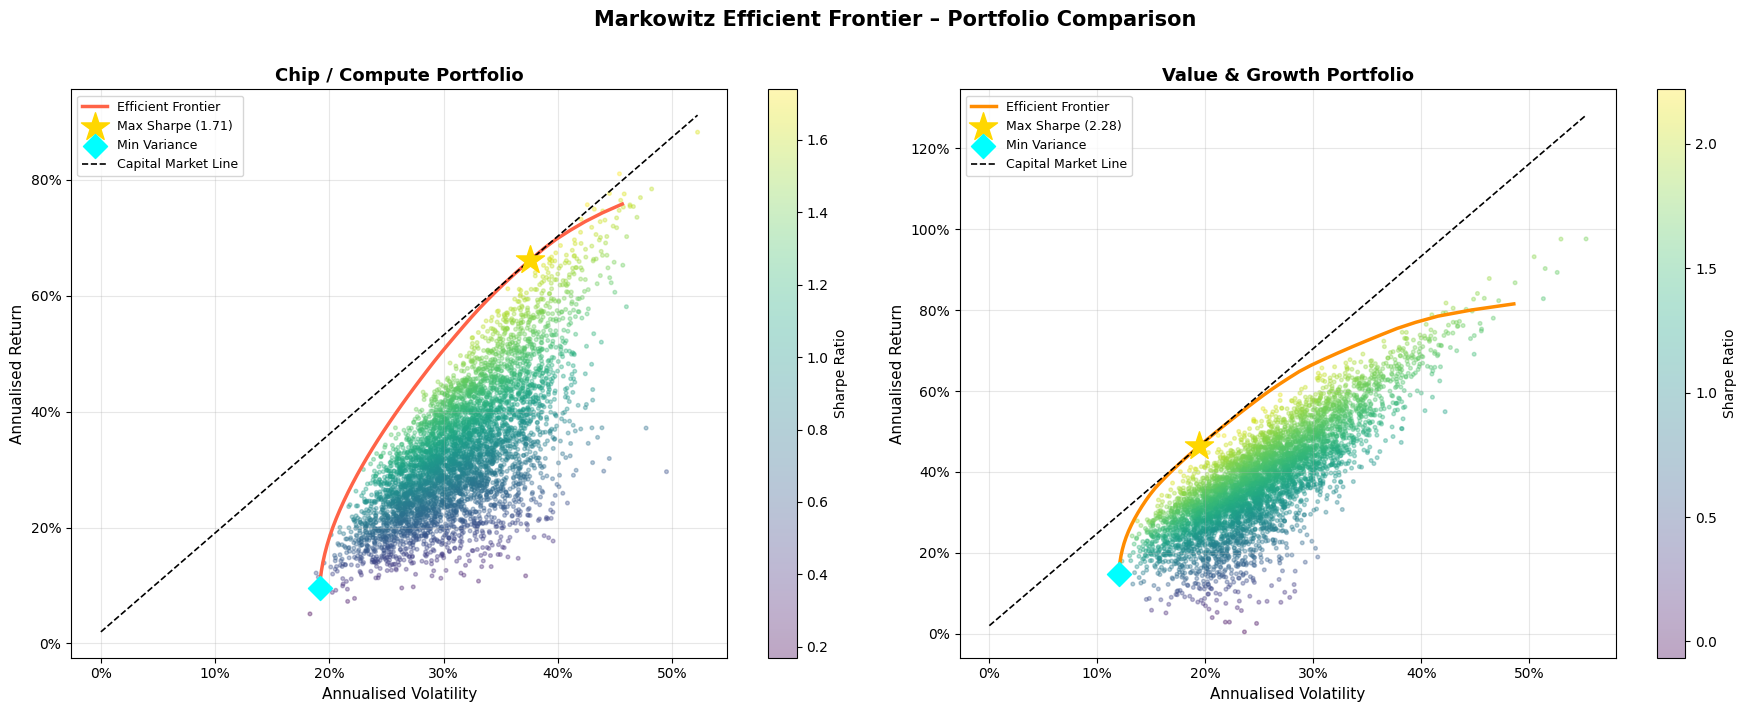

In [7]:
# ─────────────────────────────────────────
# 6. SIDE-BY-SIDE EFFICIENT FRONTIER PLOT
# ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=False)

configs = [
    (axes[0], res_chip, "Chip / Compute Portfolio",    "steelblue",     "tomato"),
    (axes[1], res_vng,  "Value & Growth Portfolio",    "mediumpurple",  "darkorange"),
]

for ax, res, title, scatter_color, frontier_color in configs:
    # Background Monte-Carlo cloud
    sc = ax.scatter(res['sim_v'], res['sim_r'],
                    c=res['sim_s'], cmap='viridis', alpha=0.35, s=7)
    plt.colorbar(sc, ax=ax, label='Sharpe Ratio')

    # Efficient frontier
    ax.plot(res['frontier_vols'], res['target_rets'],
            color=frontier_color, linewidth=2.5, label='Efficient Frontier')

    # Key portfolios
    ax.scatter(res['vol_msr'], res['ret_msr'],
               marker='*', color='gold', s=450, zorder=5,
               label=f"Max Sharpe ({res['sharpe_msr']:.2f})")
    ax.scatter(res['vol_mvp'], res['ret_mvp'],
               marker='D', color='cyan', s=150, zorder=5,
               label='Min Variance')

    # Capital market line
    x_rng = np.linspace(0, max(res['sim_v']), 200)
    ax.plot(x_rng, RISK_FREE_RATE + res['sharpe_msr'] * x_rng,
            'k--', linewidth=1.2, label='Capital Market Line')

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Annualised Volatility', fontsize=11)
    ax.set_ylabel('Annualised Return',     fontsize=11)
    ax.legend(fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.grid(True, alpha=0.3)

plt.suptitle('Markowitz Efficient Frontier – Portfolio Comparison',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()



Out-of-sample test window: 2026-01-01 to 2026-03-30


,Total Return,Annualised Return,Annualised Volatility,Sharpe,Max Drawdown
Chip - Max Sharpe,17.53%,106.21%,39.40%,2.645,-11.60%
Chip - Min Variance,29.61%,219.77%,32.37%,6.728,-11.92%
V&G - Max Sharpe,-9.00%,-34.47%,16.34%,-2.232,-14.57%
V&G - Min Variance,-2.92%,-12.45%,12.14%,-1.191,-5.65%


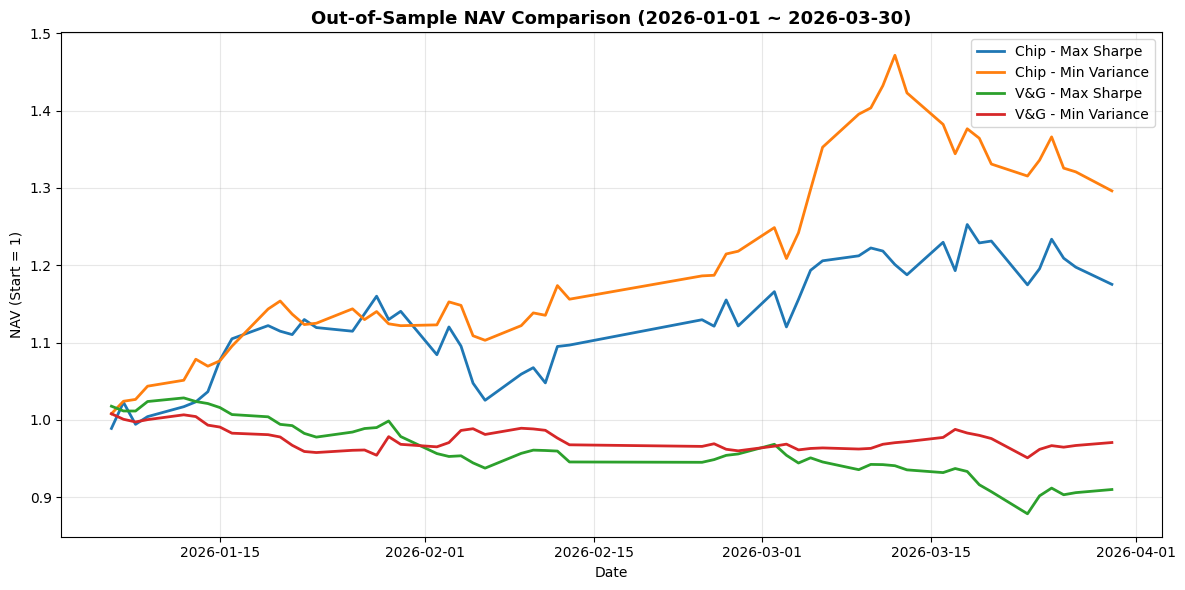

In [8]:
# ─────────────────────────────────────────
# 7. OUT-OF-SAMPLE TEST (2026-01-01 ~ 2026-03-30)
# ─────────────────────────────────────────
test_start = "2026-01-01"
test_end   = "2026-03-30"

def backtest_fixed_weight(weight_series, prices):
    """Backtest a fixed-weight portfolio on a given price panel."""
    prices_bt = prices[weight_series.index].dropna(how='any')
    rets_bt   = prices_bt.pct_change().dropna()
    port_rets = rets_bt @ weight_series.values

    nav = (1 + port_rets).cumprod()
    total_ret = nav.iloc[-1] - 1
    ann_ret   = (1 + total_ret) ** (TRADING_DAYS / len(port_rets)) - 1
    ann_vol   = port_rets.std() * np.sqrt(TRADING_DAYS)
    sharpe    = (ann_ret - RISK_FREE_RATE) / ann_vol if ann_vol > 0 else np.nan
    max_dd    = (nav / nav.cummax() - 1).min()

    return dict(
        daily_rets=port_rets,
        nav=nav,
        total_ret=total_ret,
        ann_ret=ann_ret,
        ann_vol=ann_vol,
        sharpe=sharpe,
        max_dd=max_dd
    )

# Build the 4 portfolios from in-sample optimal weights
weights_4p = {
    "Chip - Max Sharpe":   pd.Series(res_chip['w_msr'], index=res_chip['tickers']),
    "Chip - Min Variance": pd.Series(res_chip['w_mvp'], index=res_chip['tickers']),
    "V&G - Max Sharpe":    pd.Series(res_vng['w_msr'],  index=res_vng['tickers']),
    "V&G - Min Variance":  pd.Series(res_vng['w_mvp'],  index=res_vng['tickers']),
}

# Fetch OOS test prices for each stock universe
prices_chip_test = fetch_prices(res_chip['tickers'], test_start, test_end)
prices_vng_test  = fetch_prices(res_vng['tickers'],  test_start, test_end)

# Run backtests
bt_results = {}
for name, w in weights_4p.items():
    if name.startswith("Chip"):
        bt_results[name] = backtest_fixed_weight(w, prices_chip_test)
    else:
        bt_results[name] = backtest_fixed_weight(w, prices_vng_test)

# Summary table
summary = pd.DataFrame({
    name: {
        'Total Return': r['total_ret'],
        'Annualised Return': r['ann_ret'],
        'Annualised Volatility': r['ann_vol'],
        'Sharpe': r['sharpe'],
        'Max Drawdown': r['max_dd']
    }
    for name, r in bt_results.items()
}).T

print(f"\nOut-of-sample test window: {test_start} to {test_end}")
display(
    summary.style.format({
        'Total Return': '{:.2%}',
        'Annualised Return': '{:.2%}',
        'Annualised Volatility': '{:.2%}',
        'Sharpe': '{:.3f}',
        'Max Drawdown': '{:.2%}'
    })
)

# NAV comparison
plt.figure(figsize=(12, 6))
for name, r in bt_results.items():
    plt.plot(r['nav'].index, r['nav'].values, linewidth=2, label=name)

plt.title('Out-of-Sample NAV Comparison (2026-01-01 ~ 2026-03-30)', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('NAV (Start = 1)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## VaR & ES for Chip Min-Variance Portfolio

This section estimates 10-day and 60-day risk for the **Chip Portfolio Min-Variance** strategy, using historical data up to 2025-12-31.

We run three attempts under a variance-covariance framework:
1. **Normal assumption**: constant mean and volatility with Gaussian innovations.
2. **Student-t distribution**: fat-tail innovations with constant scale.
3. **Student-t + GARCH(1,1)**: fat-tail innovations plus time-varying conditional variance.

Risk metrics are reported as **loss-side VaR and ES** at a fixed confidence level.

In [4]:
# ─────────────────────────────────────────
# 8. VaR / ES FOR CHIP MIN-VARIANCE (10D & 60D)
# ─────────────────────────────────────────
from scipy.stats import norm, t
from arch import arch_model

CONF_LEVEL = 0.99
HORIZONS = [10, 60]
N_SIM = 100000

def var_es_from_samples(ret_samples, conf_level=0.99):
    q = np.quantile(ret_samples, 1 - conf_level)
    tail = ret_samples[ret_samples <= q]
    var_loss = -q
    es_loss = -tail.mean() if len(tail) > 0 else np.nan
    return var_loss, es_loss

def normal_var_es(mu_d, sigma_d, horizon, conf_level=0.99):
    z = norm.ppf(1 - conf_level)
    mu_h = mu_d * horizon
    sd_h = sigma_d * np.sqrt(horizon)
    var_loss = -(mu_h + sd_h * z)
    es_ret = mu_h - sd_h * norm.pdf(z) / (1 - conf_level)
    es_loss = -es_ret
    return var_loss, es_loss

def simulate_t_horizon(df, loc, scale, horizon, n_sim=100000, seed=42):
    rng = np.random.default_rng(seed)
    daily = t.rvs(df=df, loc=loc, scale=scale, size=(n_sim, horizon), random_state=rng)
    return daily.sum(axis=1)

def simulate_garch_t_horizon(mu, omega, alpha, beta, nu, sigma2_last, horizon, n_sim=100000, seed=42):
    rng = np.random.default_rng(seed)
    scale_std_t = np.sqrt((nu - 2) / nu) if nu > 2 else 1.0

    sigma2 = np.full(n_sim, sigma2_last, dtype=float)
    agg_ret_pct = np.zeros(n_sim, dtype=float)

    for _ in range(horizon):
        z = rng.standard_t(nu, size=n_sim) * scale_std_t
        ret_t = mu + np.sqrt(np.maximum(sigma2, 1e-12)) * z
        eps_t = ret_t - mu
        agg_ret_pct += ret_t
        sigma2 = omega + alpha * (eps_t ** 2) + beta * sigma2

    return agg_ret_pct / 100.0

# Build Chip Min-Variance daily return series from historical data (up to 2025-12-31)
w_chip_mvp = pd.Series(res_chip['w_mvp'], index=res_chip['tickers'])
prices_chip_hist = prices_chip[w_chip_mvp.index].dropna(how='any')
rets_chip_hist = prices_chip_hist.pct_change().dropna()
ret_chip_mvp = rets_chip_hist @ w_chip_mvp.values

mu_d = ret_chip_mvp.mean()
sigma_d = ret_chip_mvp.std(ddof=1)

# Attempt 1: Normal
records = []
for h in HORIZONS:
    var_h, es_h = normal_var_es(mu_d, sigma_d, h, CONF_LEVEL)
    records.append({'Method': 'Normal', 'Horizon': f'{h}D', 'VaR': var_h, 'ES': es_h})

# Attempt 2: Student-t (constant scale)
df_t, loc_t, scale_t = t.fit(ret_chip_mvp.values)
for h in HORIZONS:
    sim_ret_h = simulate_t_horizon(df_t, loc_t, scale_t, h, n_sim=N_SIM, seed=42 + h)
    var_h, es_h = var_es_from_samples(sim_ret_h, CONF_LEVEL)
    records.append({'Method': 'Student-t', 'Horizon': f'{h}D', 'VaR': var_h, 'ES': es_h})

# Attempt 3: Student-t + GARCH(1,1)
ret_chip_mvp_pct = ret_chip_mvp * 100
garch_mod = arch_model(ret_chip_mvp_pct, mean='Constant', vol='GARCH', p=1, q=1, dist='t')
garch_res = garch_mod.fit(disp='off')
garch_p = garch_res.params

mu_g = garch_p.get('mu', 0.0)
omega_g = garch_p['omega']
alpha_g = garch_p['alpha[1]']
beta_g = garch_p['beta[1]']
nu_g = garch_p['nu']
sigma2_last = float(garch_res.conditional_volatility.iloc[-1] ** 2)

for h in HORIZONS:
    sim_ret_h = simulate_garch_t_horizon(
        mu=mu_g, omega=omega_g, alpha=alpha_g, beta=beta_g, nu=nu_g,
        sigma2_last=sigma2_last, horizon=h, n_sim=N_SIM, seed=2026 + h
    )
    var_h, es_h = var_es_from_samples(sim_ret_h, CONF_LEVEL)
    records.append({'Method': 'Student-t + GARCH(1,1)', 'Horizon': f'{h}D', 'VaR': var_h, 'ES': es_h})

risk_summary = pd.DataFrame(records)
print(f"Confidence level: {CONF_LEVEL:.0%}")
display(risk_summary.style.format({'VaR': '{:.2%}', 'ES': '{:.2%}'}))

Confidence level: 99%


,Method,Horizon,VaR,ES
0,Normal,10D,8.67%,9.98%
1,Normal,60D,19.83%,23.07%
2,Student-t,10D,9.39%,11.43%
3,Student-t,60D,21.80%,25.31%
4,"Student-t + GARCH(1,1)",10D,9.42%,12.18%
5,"Student-t + GARCH(1,1)",60D,22.30%,27.41%


In [5]:
# ─────────────────────────────────────────
# 9. VaR / ES VIA HISTORICAL SIMULATION (BOOTSTRAP)
# ─────────────────────────────────────────
CONF_LEVEL = 0.99
HORIZONS = [10, 60]
N_SIM = 100000

def bootstrap_horizon_returns(ret_series, horizon, n_sim=100000, seed=42):
    rng = np.random.default_rng(seed)
    hist = ret_series.values
    idx = rng.integers(0, len(hist), size=(n_sim, horizon))
    sampled = hist[idx]
    return sampled.sum(axis=1)

# Build Chip Min-Variance daily return series from historical data (up to 2025-12-31)
w_chip_mvp = pd.Series(res_chip['w_mvp'], index=res_chip['tickers'])
prices_chip_hist = prices_chip[w_chip_mvp.index].dropna(how='any')
rets_chip_hist = prices_chip_hist.pct_change().dropna()
ret_chip_mvp = rets_chip_hist @ w_chip_mvp.values

# Bootstrap Historical Simulation
records_hs = []
for h in HORIZONS:
    sim_ret_h = bootstrap_horizon_returns(ret_chip_mvp, h, n_sim=N_SIM, seed=3000 + h)
    var_h, es_h = var_es_from_samples(sim_ret_h, CONF_LEVEL)
    records_hs.append({'Method': 'Historical Simulation (Bootstrap)', 'Horizon': f'{h}D', 'VaR': var_h, 'ES': es_h})

risk_summary_hs = pd.DataFrame(records_hs)
print(f"Confidence level: {CONF_LEVEL:.0%}")
display(risk_summary_hs.style.format({'VaR': '{:.2%}', 'ES': '{:.2%}'}))

Confidence level: 99%


,Method,Horizon,VaR,ES
0,Historical Simulation (Bootstrap),10D,8.93%,10.57%
1,Historical Simulation (Bootstrap),60D,19.75%,23.03%


In [6]:
# ─────────────────────────────────────────
# 10. VaR / ES VIA MONTE CARLO (GBM + NORMAL)
# ─────────────────────────────────────────
CONF_LEVEL = 0.99
HORIZONS = [10, 60]
N_SIM = 100000

def simulate_gbm_horizon_returns(mu_d, sigma_d, horizon, n_sim=100000, seed=42):
    rng = np.random.default_rng(seed)
    z = rng.standard_normal((n_sim, horizon))

    # Under GBM, log-return increment: (mu - 0.5*sigma^2)dt + sigma*sqrt(dt)*z
    drift = (mu_d - 0.5 * sigma_d ** 2)
    log_increments = drift + sigma_d * z
    log_ret_h = log_increments.sum(axis=1)

    # Convert horizon log-return to simple return
    return np.exp(log_ret_h) - 1

# Build Chip Min-Variance daily return series from historical data (up to 2025-12-31)
w_chip_mvp = pd.Series(res_chip['w_mvp'], index=res_chip['tickers'])
prices_chip_hist = prices_chip[w_chip_mvp.index].dropna(how='any')
rets_chip_hist = prices_chip_hist.pct_change().dropna()
ret_chip_mvp = rets_chip_hist @ w_chip_mvp.values

# Estimate GBM parameters from historical daily returns
mu_d = ret_chip_mvp.mean()
sigma_d = ret_chip_mvp.std(ddof=1)

# Monte Carlo (GBM + Normal innovations)
records_mc = []
for h in HORIZONS:
    sim_ret_h = simulate_gbm_horizon_returns(mu_d, sigma_d, h, n_sim=N_SIM, seed=5000 + h)
    var_h, es_h = var_es_from_samples(sim_ret_h, CONF_LEVEL)
    records_mc.append({'Method': 'Monte Carlo (GBM + Normal)', 'Horizon': f'{h}D', 'VaR': var_h, 'ES': es_h})

risk_summary_mc = pd.DataFrame(records_mc)
print(f"Confidence level: {CONF_LEVEL:.0%}")
display(risk_summary_mc.style.format({'VaR': '{:.2%}', 'ES': '{:.2%}'}))

Confidence level: 99%


,Method,Horizon,VaR,ES
0,Monte Carlo (GBM + Normal),10D,8.33%,9.51%
1,Monte Carlo (GBM + Normal),60D,18.47%,20.99%
